# Major Crypto Currency Weekend Movement

**Thesis:** 
With the introduction of Bitcoin's ETF on January 10th, 2024, and later the Ethereum ETF on July 23rd, 2024, people were allowed to trade these major cryptocurrencies during regular market hours. This trading could be the main cause of price movement during market hours. We would like to explore whether, during the period from the New Stock Exchange's Friday closing at 20:00 UTC to the Japanese Stock Exchange's Monday opening at 00:00 UTC, price movement is negligible. If price movement over the market's weekend close follows certain patterns, it opens up the possibility of certain trades to be performed on CEXs and DEXs. 

In this report, we will perform EDA on a sample of Bitcoin, Ethereum, and Solana from a period of ten weeks. Solona was selected for comparison because it is the only comparable cryptocurrency and *does not* have an ETF.

The data for this project was sourced from [Binance](https://www.binance.us/institutions/market-history) Historical Data webpage. 

Find exact directory where files are stored. 

In [1]:
import os
os.getcwd()


'/Users/mkelleher/Downloads/BTC_ETH_price/crypto-notebooks'

Merge daily BTC, ETH, and SOL files each into their own DataFrame

In [4]:
import glob 
import zipfile
import pandas as pd 
from io import BytesIO

# Set path where zip files are stored 
path = '/Users/mkelleher/Downloads/BTC_ETH_price/crypto-notebooks'

# Define function to read zip files into a DataFrame 
def read_zip_files(file_list, asset_name):
    dfs = []
    for file in file_list:
        with zipfile.ZipFile(file, 'r') as z:
            for filename in z.namelist():
                with z.open(filename) as f:
                    df = pd.read_csv(f)
                    df['asset'] = asset_name # ass the asset name
                    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
                    df['close_time'] = pd.to_datetime(df['close_time'], unit='ms')
                    dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# Use glob to get lists of mathcing files 
btc_files = sorted(glob.glob(f'{path}/BTCUSD-1h-*.zip'))
eth_files = sorted(glob.glob(f'{path}/ETHUSD-1h-*.zip'))
sol_files = sorted(glob.glob(f'{path}/SOLUSD-1h-*.zip'))

# Read and combine files into separate DataFrames 
btc_df = read_zip_files(btc_files, 'BTC')
eth_df = read_zip_files(eth_files, 'ETH')
sol_df = read_zip_files(sol_files, 'SOL')


In [107]:
print("The max value from the 'open_time' column is ", btc_df['open_time'].max())
print("The min value from the 'open_time' column is ", btc_df['open_time'].min())
btc_df.head()

The max value from the 'open_time' column is  2025-05-02 23:00:00
The min value from the 'open_time' column is  2025-02-20 00:00:00


,open_time,open,high,low,close,volume,close_time,quote_volume,count,taker_buy_base_volume,taker_buy_quote_volume,asset
0,2025-02-20 00:00:00,96498.51,96768.81,96498.51,96768.81,0.04291,2025-02-20 00:59:59.999,4143.930565,32,0.02431,2348.771842,BTC
1,2025-02-20 01:00:00,96768.81,96768.81,96768.81,96768.81,0.00458,2025-02-20 01:59:59.999,443.201150,7,0.00000,0.000000,BTC
2,2025-02-20 02:00:00,96768.81,96926.76,96680.48,96926.76,0.05251,2025-02-20 02:59:59.999,5089.213754,10,0.05128,4970.272031,BTC
3,2025-02-20 03:00:00,97210.49,97265.06,97210.49,97265.06,0.00313,2025-02-20 03:59:59.999,304.366328,4,0.00000,0.000000,BTC
4,2025-02-20 04:00:00,96995.40,97345.52,96995.40,97065.37,0.02514,2025-02-20 04:59:59.999,2443.982197,12,0.02383,2316.839856,BTC


Merge into one combined DataFrame.

In [9]:
combined_df = pd.concat([btc_df, eth_df, sol_df], ignore_index=True)

Set close_time as the index. 

In [12]:
combined_df.set_index('close_time', inplace=True)
combined_df.sort_index(inplace=True)

Drop columns not needed for the analysis. 

In [14]:
columns_to_drop = ['volume','quote_volume','count','taker_buy_base_volume','taker_buy_quote_volume']
cleaned_df = combined_df.drop(columns=columns_to_drop)

In [16]:
cleaned_df.head
print(cleaned_df['open_time'].dtype)

datetime64[ns]


Complete the following steps to create a visual that highlights price movements over the weekend. 
* Loop through each asset (BTC, ETH, SOL).
* Plot open and close prices.
* Identify weekend periods.
* Use matplotlib to shade weekends with axvspan().

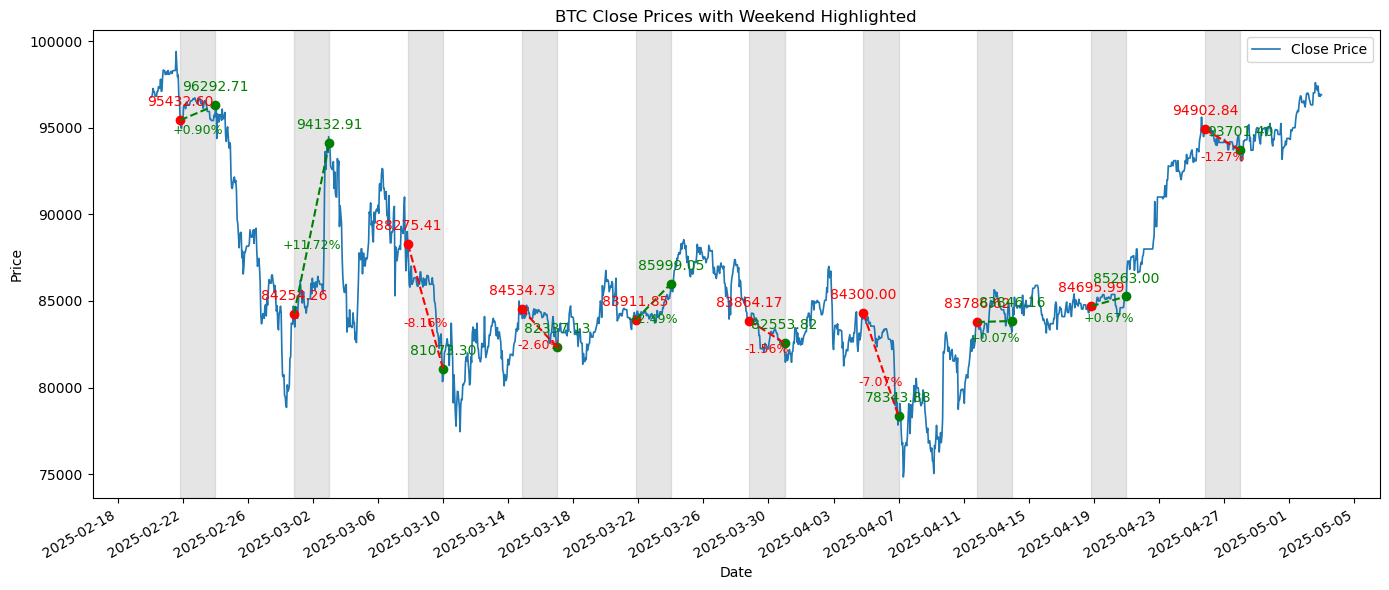

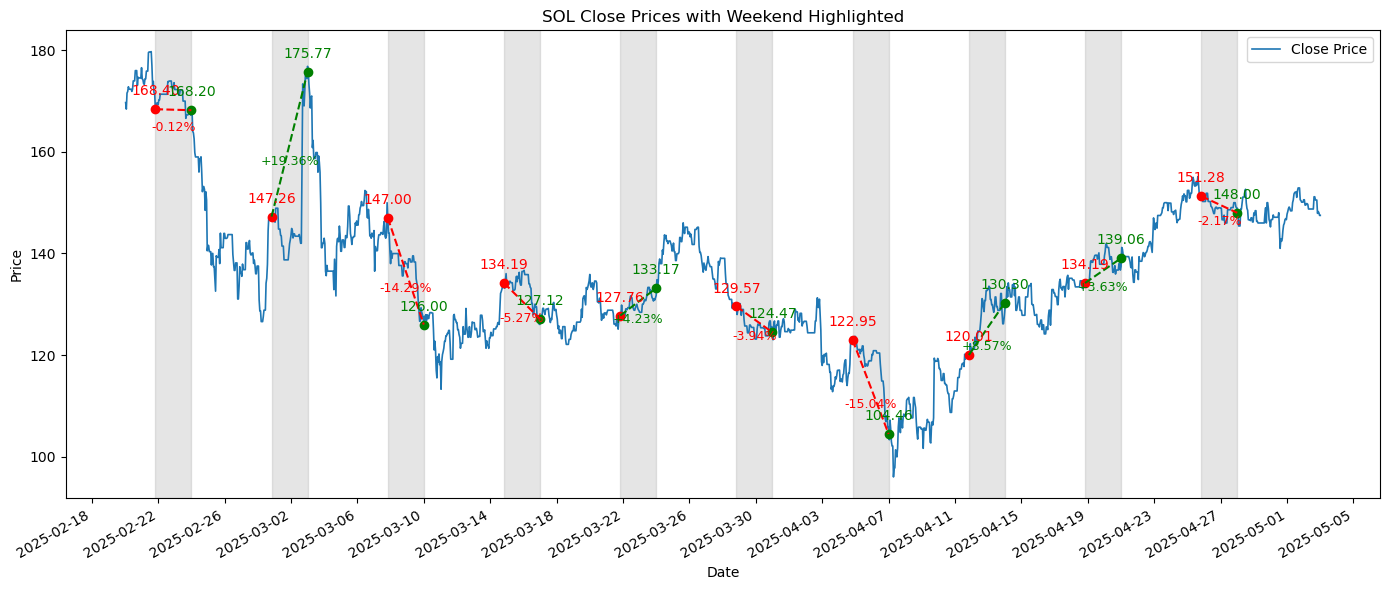

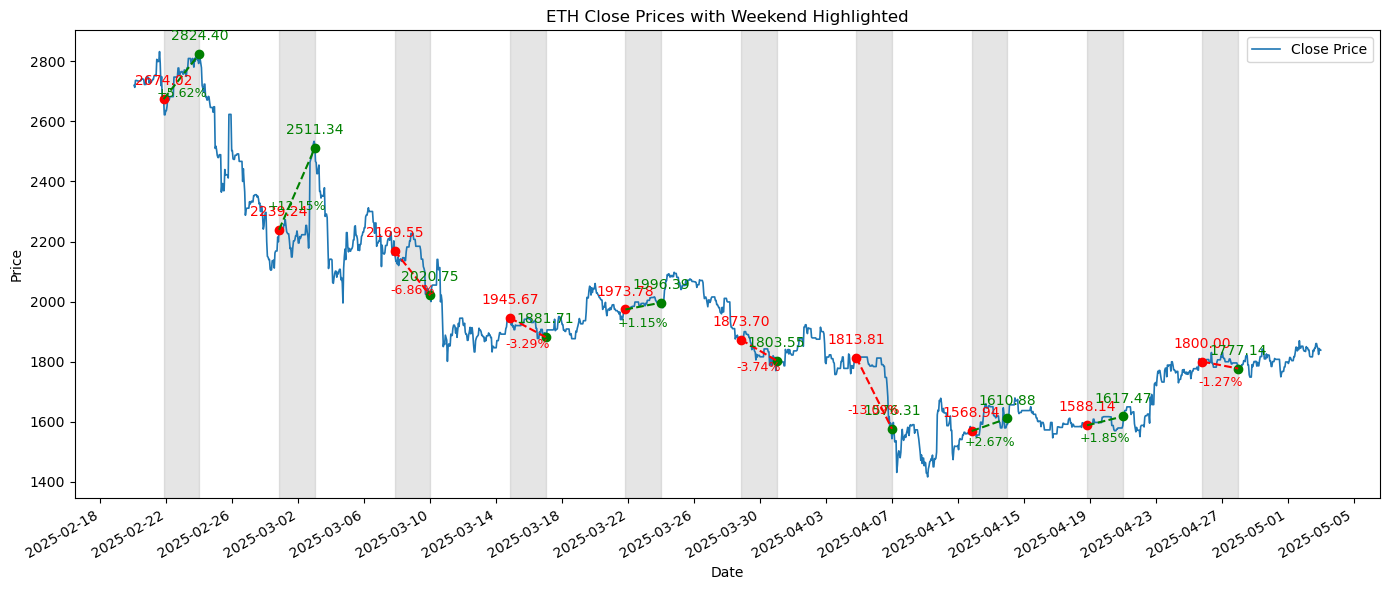

In [19]:
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 

# Get unique assets
assets = cleaned_df['asset'].unique()


# Loop through each asset 
for asset in assets:
    df = cleaned_df[cleaned_df['asset'] == asset]
    fig, ax = plt.subplots(figsize=(14,6))
    # Plot close prices
    ax.plot(df.index, df['close'], label='Close Price', linewidth=1.2)
    # Find Fridays at 20:00 and Mondays at 00:00
    fridays = df[(df.index.weekday == 4) & (df.index.time == pd.Timestamp('19:59:59.999').time())].index
    mondays = df[(df.index.weekday == 6) & (df.index.time == pd.Timestamp('23:59:59.999').time())].index

    #Build weekend ranges
    for friday in fridays:
        monday = mondays[mondays > friday]
        if not monday.empty:
            monday_time = monday[0]
            #Highlight the weekend range
            ax.axvspan(friday, monday_time, color='gray', alpha=0.2)

            # Get Friday's close price 
            friday_close = df.loc[friday, 'close']
            ax.plot(friday, friday_close, 'ro') # red dot 
            ax.annotate(f'{friday_close:.2f}', (friday, friday_close),
                        textcoords='offset points', xytext=(0,10), ha = 'center', color = 'red')

            # Get Monday open price using open_time 
            monday_row = df[(df['open_time'] >= monday_time - pd.Timedelta(minutes=1)) & (df['open_time'] <= monday_time + pd.Timedelta(minutes=1))]
            if not monday_row.empty:
                monday_open = monday_row.iloc[0]['open']
                ax.plot(monday_time, monday_open, 'go') # green dot 
                ax.annotate(f'{monday_open:.2f}', (monday_time, monday_open),
                            textcoords='offset points', xytext=(0,10), ha='center', color = 'green')
                # Determine percent change
                percent_change = ((monday_open - friday_close) / friday_close) * 100

                # Choose color based on direction
                line_color = 'green' if percent_change > 0 else 'red'

                # Draw a dashed line between Friday and Monday
                ax.plot([friday, monday_time], [friday_close, monday_open],
                color=line_color, linestyle='--', linewidth=1.5)

                # Annotate % change at the midpoint
                mid_time = friday + (monday_time - friday) / 2
                mid_price = (friday_close + monday_open) / 2
                ax.annotate(f'{percent_change:+.2f}%', (mid_time, mid_price),
                            textcoords='offset points', xytext=(0, -15), ha='center',
                            fontsize=9, color=line_color)

        
    
    #Formatting 
    ax.set_title(f'{asset} Close Prices with Weekend Highlighted')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval = 4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
        

Create a weekend gaps summary table

In [22]:
# intialize summary list 
summary = []

for asset in cleaned_df['asset'].unique():
    df = cleaned_df[cleaned_df['asset'] == asset]

    # Find Fridays and Mondays 
    fridays = df[(df.index.weekday == 4) & (df.index.time == pd.Timestamp('19:59:59.999').time())].index
    mondays = df[(df.index.weekday == 6) & (df.index.time == pd.Timestamp('23:59:59.999').time())].index

    for friday in fridays:
        monday = mondays[mondays > friday]
        if not monday.empty:
            monday_time = monday[0]
            friday_close = df.loc[friday, 'close']
            monday_row = df[(df['open_time'] >= monday_time - pd.Timedelta(minutes=1)) &
                            (df['open_time'] <= monday_time + pd.Timedelta(minutes=1))]
            if not monday_row.empty:
                monday_open = monday_row.iloc[0]['open']
                pct_change = ((monday_open - friday_close) / friday_close) * 100 

                # Append to summary
                summary.append({
                    'asset': asset,
                    'friday_time': friday,
                    'friday_close': friday_close,
                    'monday_time': monday_time, 
                    'monday_open': monday_open,
                    'pct_change': pct_change
                })

# Convert to DataFrame 
summary_df = pd.DataFrame(summary)

#Preview 
summary_df.head()

,asset,friday_time,friday_close,monday_time,monday_open,pct_change
0,BTC,2025-02-21 19:59:59.999,95432.60,2025-02-23 23:59:59.999,96292.71,0.901275
1,BTC,2025-02-28 19:59:59.999,84254.26,2025-03-02 23:59:59.999,94132.91,11.724808
2,BTC,2025-03-07 19:59:59.999,88275.41,2025-03-09 23:59:59.999,81073.30,-8.158682
3,BTC,2025-03-14 19:59:59.999,84534.73,2025-03-16 23:59:59.999,82337.13,-2.599642
4,BTC,2025-03-21 19:59:59.999,83911.85,2025-03-23 23:59:59.999,85999.05,2.487372


Turn summary chat into a Bar Chart per Asset.

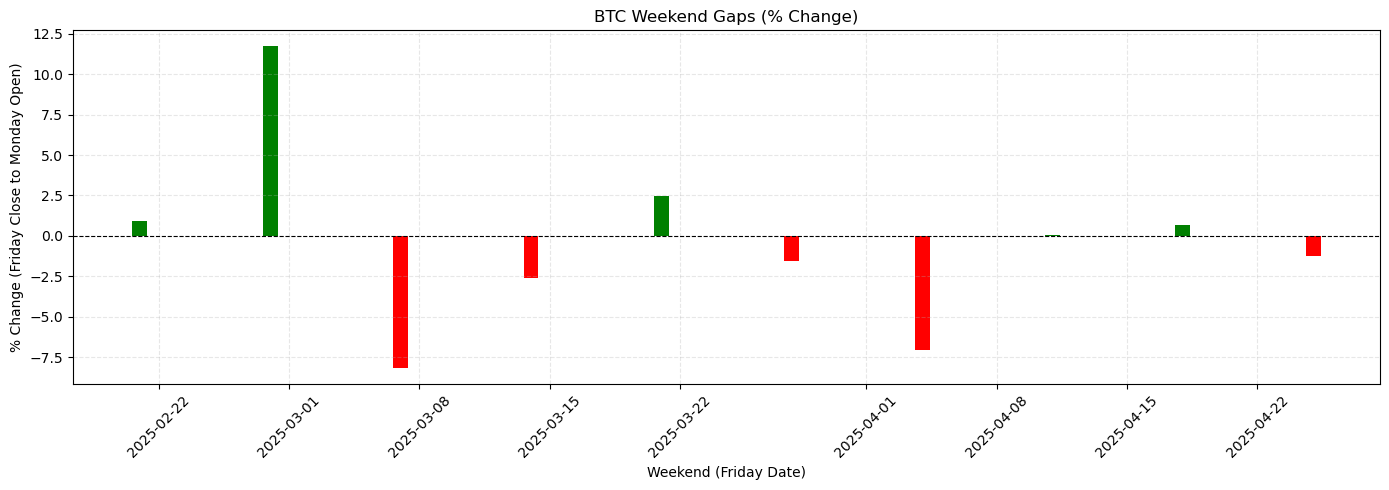

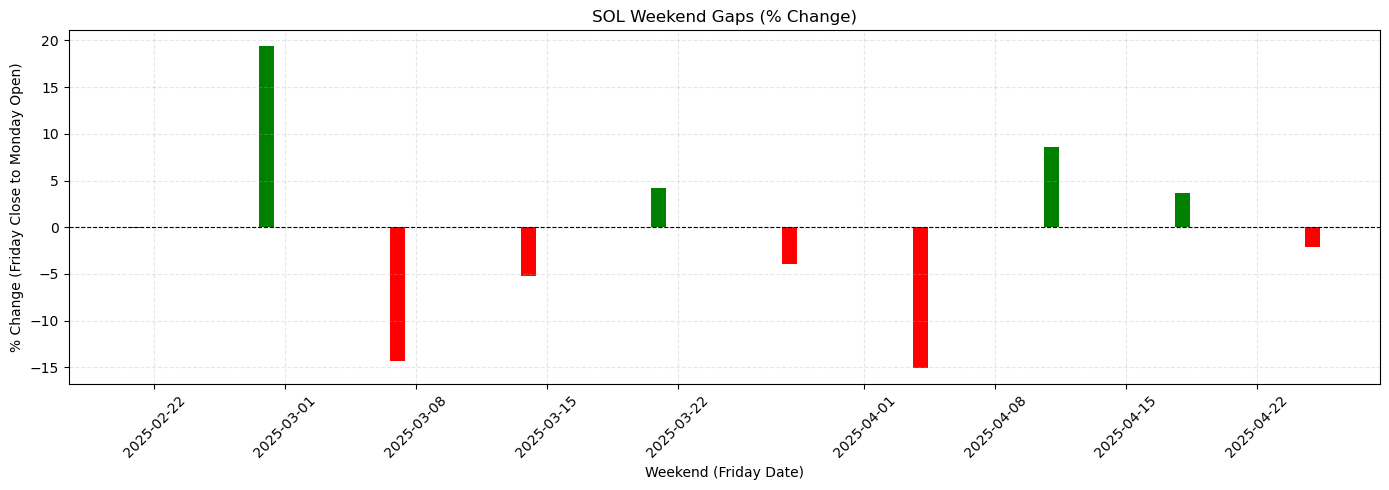

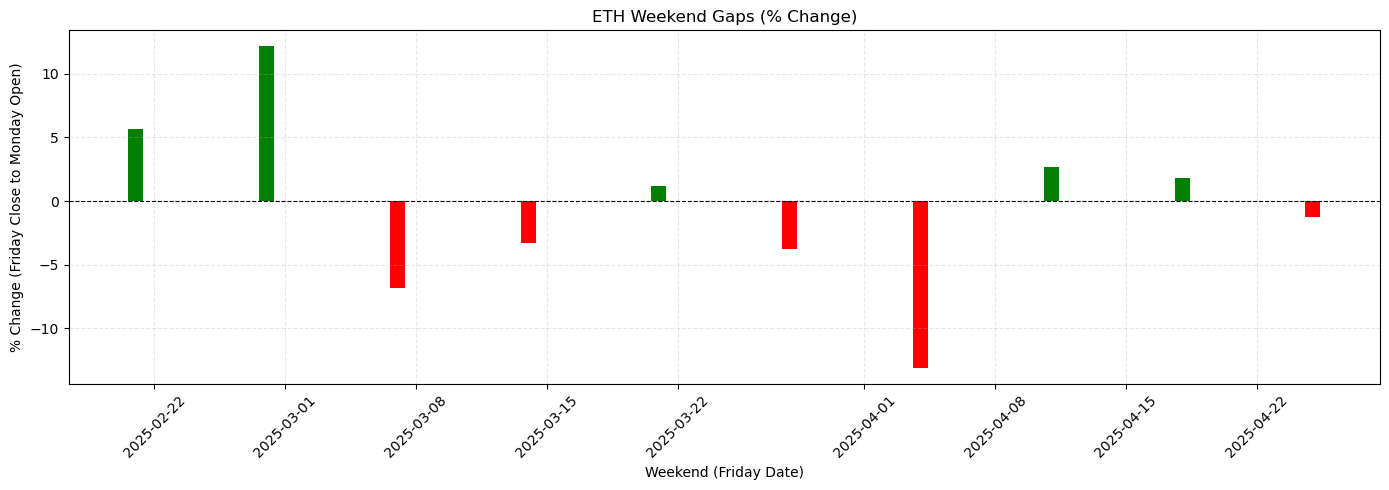

In [25]:
import matplotlib.pyplot as plt

# Convert time column to date (optional, to simplify x-axis)
summary_df['weekend'] = summary_df['friday_time'].dt.date

# Plot one bar chart per asset
for asset in summary_df['asset'].unique():
    asset_df = summary_df[summary_df['asset'] == asset]

    # Color bars based on direction
    colors = asset_df['pct_change'].apply(lambda x: 'green' if x > 0 else 'red')

    plt.figure(figsize=(14, 5))
    plt.bar(asset_df['weekend'], asset_df['pct_change'], color=colors)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    plt.title(f"{asset} Weekend Gaps (% Change)")
    plt.xlabel("Weekend (Friday Date)")
    plt.ylabel("% Change (Friday Close to Monday Open)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.savefig(f"{asset}_weekend_gaps_bar.png", dpi=300)
    plt.show()


Create one visual that shows the summary chart for side-by-side comparison. 

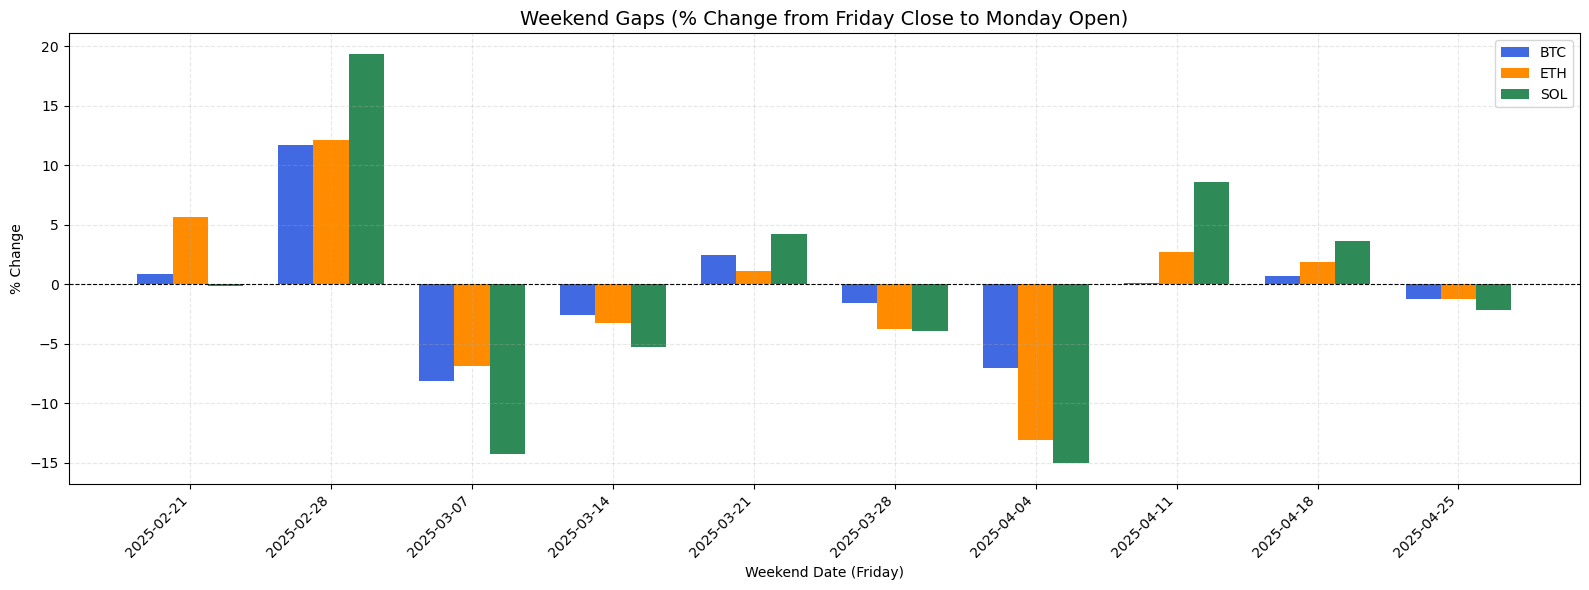

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the weekend date is clean for x-axis
summary_df['weekend'] = pd.to_datetime(summary_df['friday_time'].dt.date)

# Pivot the table: index = weekend, columns = asset, values = pct_change
pivot_df = summary_df.pivot(index='weekend', columns='asset', values='pct_change').sort_index()

# Define colors for each asset
asset_colors = {
    'BTC': 'royalblue',
    'ETH': 'darkorange',
    'SOL': 'seagreen'
}

# Plot setup
fig, ax = plt.subplots(figsize=(16, 6))
bar_width = 0.25
x = np.arange(len(pivot_df.index))  # base x positions

# Plot each asset’s bars
for i, asset in enumerate(pivot_df.columns):
    offsets = x + (i - len(pivot_df.columns) / 2) * bar_width + bar_width / 2
    ax.bar(offsets,
           pivot_df[asset],
           width=bar_width,
           label=asset,
           color=asset_colors.get(asset, 'gray'))

# Formatting
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Weekend Gaps (% Change from Friday Close to Monday Open)", fontsize=14)
ax.set_ylabel("% Change")
ax.set_xlabel("Weekend Date (Friday)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index.strftime('%Y-%m-%d'), rotation=45, ha='right')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("grouped_weekend_gaps_bar.png", dpi=300)
plt.show()


The initial visuals do not show any visible evidence Monday's opening price is similar to Friday's close price. 
We will perform statistical analysis to see if that shows any evidence. 

Weekday Returns (Monday Open -> Friday Close)

In [30]:
cleaned_df.index.name

'close_time'

In [34]:
weekday_summary = []

for asset in cleaned_df['asset'].unique():
    df = cleaned_df[cleaned_df['asset'] == asset].copy()

    # Make sure it's sorted by close_time (the index)
    df = df.sort_index()

    # Monday 00:00:00 UTC (Tokyo open)
    mondays = df[(df['open_time'].dt.weekday == 0) &
                 (df['open_time'].dt.time == pd.Timestamp('00:00:00').time())]

    # Friday 19:59:59.999 UTC (NYSE close)
    fridays = df[(df.index.weekday == 4) &
                 (df.index.time == pd.Timestamp('19:59:59.999').time())]

    for _, monday_row in mondays.iterrows():
        monday_time = monday_row['open_time']

        # Find the first Friday after this Monday
        future_fridays = fridays[fridays.index > monday_time]
        if not future_fridays.empty:
            friday_row = future_fridays.iloc[0]
            friday_time = friday_row.name  # Index is close_time

            monday_open = monday_row['open']
            friday_close = friday_row['close']
            pct_change = ((friday_close - monday_open) / monday_open) * 100

            weekday_summary.append({
                'asset': asset,
                'monday_time': monday_time,
                'friday_time': friday_time,
                'weekday_return': pct_change
            })

# Convert to DataFrame
weekday_df = pd.DataFrame(weekday_summary)

In [36]:
weekday_df.head()
weekday_df.describe()

,monday_time,friday_time,weekday_return
count,30,30,30.000000
mean,2025-03-27 12:00:00,2025-04-01 07:59:59.999000064,-0.500074
min,2025-02-24 00:00:00,2025-02-28 19:59:59.999000,-20.718029
25%,2025-03-10 00:00:00,2025-03-14 19:59:59.999000064,-3.462417
50%,2025-03-27 12:00:00,2025-04-01 07:59:59.999000064,0.536170
75%,2025-04-14 00:00:00,2025-04-18 19:59:59.999000064,4.148313
max,2025-04-28 00:00:00,2025-05-02 19:59:59.999000,14.886081
std,NaN,NaN,8.355007


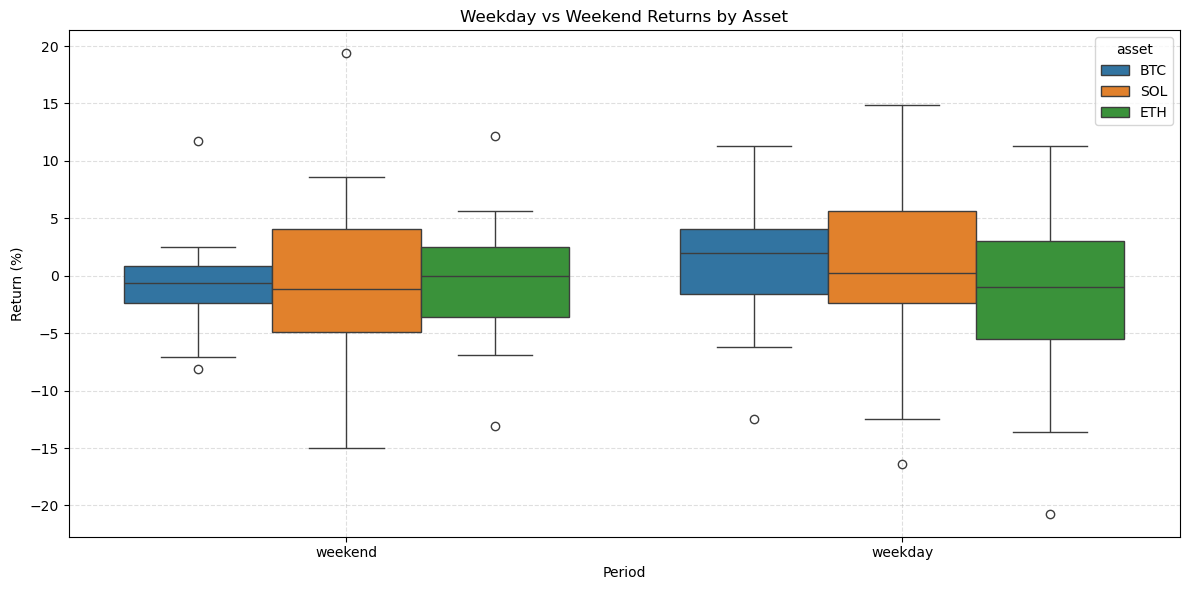

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare weekend returns
weekend_stats = summary_df[['asset', 'friday_time', 'pct_change']].copy()
weekend_stats['period'] = 'weekend'
weekend_stats.rename(columns={'pct_change': 'return', 'friday_time': 'start_time'}, inplace=True)

# Prepare weekday returns
weekday_stats = weekday_df[['asset', 'monday_time', 'weekday_return']].copy()
weekday_stats['period'] = 'weekday'
weekday_stats.rename(columns={'weekday_return': 'return', 'monday_time': 'start_time'}, inplace=True)

# Combine
combined_returns = pd.concat([weekend_stats, weekday_stats])

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_returns, x='period', y='return', hue='asset')
plt.title("Weekday vs Weekend Returns by Asset")
plt.ylabel("Return (%)")
plt.xlabel("Period")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Create the box plot without the outliers. 

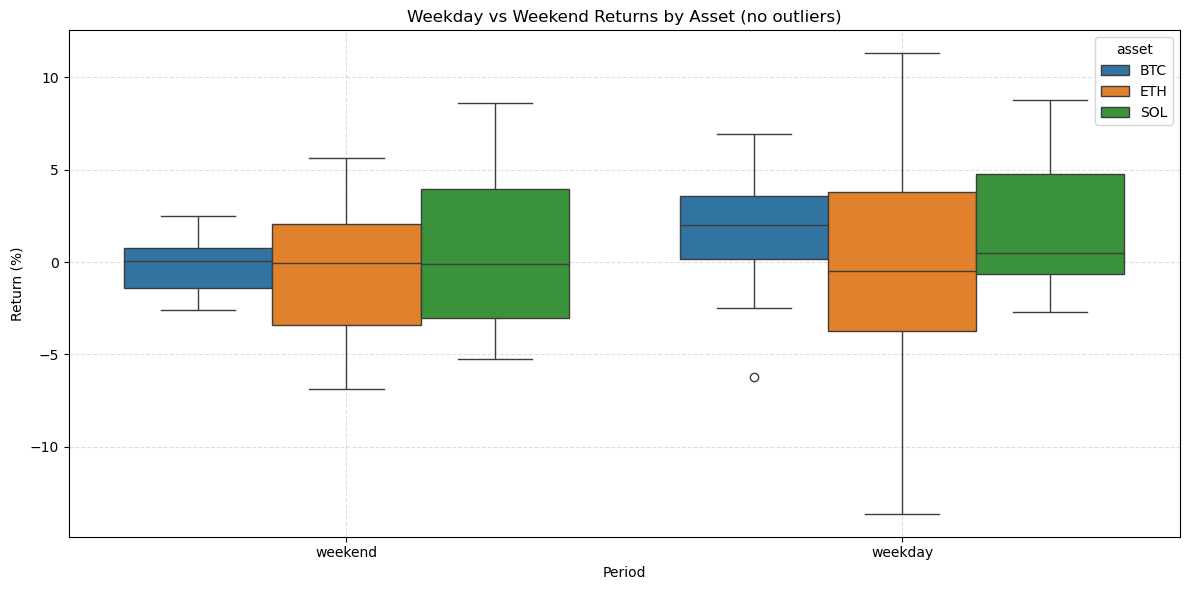

In [63]:
def remove_outliers(df, group_cols, value_col):
    filtered = []
    for keys, group in df.groupby(group_cols):
        q1 = group[value_col].quantile(0.25)
        q3 = group[value_col].quantile(0.75)
        iqr = q3 - q1 
        lower = q1 - 1.0 * iqr 
        upper = q3 + 1.0 * iqr
        group_filtered = group [(group[value_col] >= lower) & (group[value_col] <= upper)]
        filtered.append(group_filtered)
    return pd.concat(filtered)

# Apply outlier filtering by asset and period 
cleaned_returns = remove_outliers(combined_returns, ['asset', 'period'], 'return')

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=cleaned_returns, x='period', y='return', hue='asset', order=['weekend', 'weekday'])
plt.title("Weekday vs Weekend Returns by Asset (no outliers)")
plt.ylabel("Return (%)")
plt.xlabel("Period")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

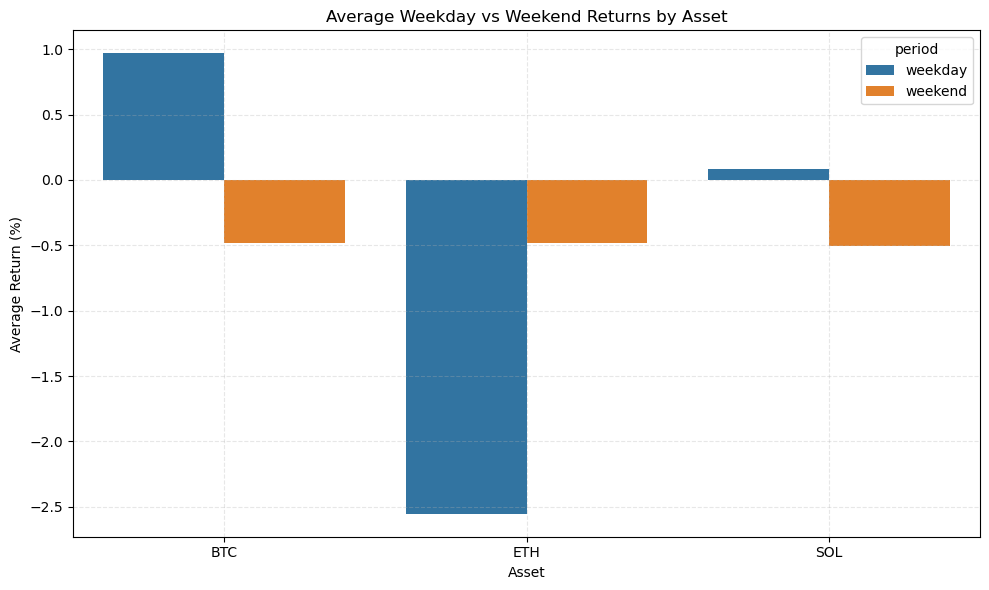

In [42]:
# Group and aggregate
mean_returns = combined_returns.groupby(['asset', 'period'])['return'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=mean_returns, x='asset', y='return', hue='period')
plt.title("Average Weekday vs Weekend Returns by Asset")
plt.ylabel("Average Return (%)")
plt.xlabel("Asset")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("weekday_vs_weekend_returns.png", dpi=300)
plt.show()